In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report,confusion_matrix, roc_auc_score,precision_recall_curve,average_precision_score,roc_curve,f1_score
import matplotlib.pyplot as plt
import warnings


import seaborn as sns
import matplotlib.lines as mlines
from matplotlib.gridspec import GridSpec
import xgboost as xgb
from sklearn.metrics import (
    precision_score, 
    recall_score, 
)

warnings.filterwarnings('ignore')

In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

Device: cpu


# NN Learning Curve (train vs. val) --- No Overfitting plot

In [4]:
df = pd.read_parquet('../../data/processed/engineered_features_nn.parquet')

In [5]:
if 'gsr_count' in df.columns:
    df = df.drop(columns=['gsr_count'])
    print('Dropped gsr_count')

meta_cols = ['stub_id', 'particle_id', 'label', 'target', 'final_class']
feature_cols = [c for c in df.columns if c not in meta_cols]

print(f'Shape: {df.shape}')
print(f'Features: {len(feature_cols)}')
print(f'Label distribution:\n{df["label"].value_counts()}')

Dropped gsr_count
Shape: (2294985, 61)
Features: 56
Label distribution:
label
Non_GSR    1216039
GSR        1078946
Name: count, dtype: int64


## Group-Aware Train/Val/Test Split

In [6]:
X = df[feature_cols].values.astype(np.float32)
y = df['target'].values.astype(np.float32)
groups = df['stub_id'].values

gss1 = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
trainval_idx, test_idx = next(gss1.split(X, y, groups))
X_trainval, X_test_raw = X[trainval_idx], X[test_idx]
y_trainval, y_test = y[trainval_idx], y[test_idx]
groups_trainval = groups[trainval_idx]

gss2 = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=42)
train_idx_rel, val_idx_rel = next(gss2.split(X_trainval, y_trainval, groups_trainval))
X_train_raw = X_trainval[train_idx_rel]
X_val_raw = X_trainval[val_idx_rel]
y_train = y_trainval[train_idx_rel]
y_val = y_trainval[val_idx_rel]
groups_train = groups_trainval[train_idx_rel]

In [7]:
train_stubs = set(groups_train)
val_stubs = set(groups_trainval[val_idx_rel])
test_stubs = set(groups[test_idx])

assert len(train_stubs & val_stubs) == 0
assert len(train_stubs & test_stubs) == 0
assert len(val_stubs & test_stubs) == 0
print(f'Train: {len(X_train_raw):,} ({y_train.mean():.1%} GSR)')
print(f'Val: {len(X_val_raw):,} ({y_val.mean():.1%} GSR)')
print(f'Test: {len(X_test_raw):,} ({y_test.mean():.1%} GSR)')
print('No stub overlap confirmed.')

Train: 1,444,147 (49.7% GSR)
Val: 407,614 (37.1% GSR)
Test: 443,224 (47.4% GSR)
No stub overlap confirmed.


In [9]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_val = scaler.transform(X_val_raw)
X_test = scaler.transform(X_test_raw)

## MLP Architecture (Tunable)

In [10]:
class TunableMLP(nn.Module):
    def __init__(self, input_dim, hidden_dim=256, n_layers=2, dropout=0.3):
        super().__init__()
        layers = []
        prev_dim = input_dim
        for _ in range(n_layers):
            layers.extend([
                nn.Linear(prev_dim, hidden_dim),
                nn.ReLU(),
                nn.Dropout(dropout),
            ])
            prev_dim = hidden_dim
        layers.append(nn.Linear(prev_dim, 1))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

In [11]:
def train_model(X_tr, y_tr, X_vl, y_vl, input_dim,
                hidden_dim=256, n_layers=2, dropout=0.3,
                lr=0.001, batch_size=4096, max_epochs=15, patience=5):
    """Train MLP with given hyperparameters, return best model state and metrics."""
    model = TunableMLP(input_dim, hidden_dim, n_layers, dropout).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.BCEWithLogitsLoss()

    train_ds = TensorDataset(torch.tensor(X_tr, dtype=torch.float32),
                              torch.tensor(y_tr, dtype=torch.float32))
    val_ds = TensorDataset(torch.tensor(X_vl, dtype=torch.float32),
                            torch.tensor(y_vl, dtype=torch.float32))
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)

    best_val_loss = float('inf')
    best_state = None
    epochs_no_improve = 0
    train_losses, val_losses = [], []

    for epoch in range(max_epochs):
        model.train()
        epoch_loss, n_batches = 0, 0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            logits = model(xb).squeeze()
            loss = criterion(logits, yb)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
            n_batches += 1
        train_losses.append(epoch_loss / n_batches)

        model.eval()
        val_loss, n_val = 0, 0
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(device), yb.to(device)
                val_loss += criterion(model(xb).squeeze(), yb).item()
                n_val += 1
        val_losses.append(val_loss / n_val)

        if val_losses[-1] < best_val_loss:
            best_val_loss = val_losses[-1]
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                break

    model.load_state_dict(best_state)
    return model, best_val_loss, train_losses, val_losses

In [12]:
param_grid = [
    {'lr': 1e-3, 'dropout': 0.3, 'hidden_dim': 256, 'n_layers': 2},  #wider
]

print(f'Total configurations: {len(param_grid)}')

Total configurations: 1


In [13]:
results = []
for i, params in enumerate(param_grid):
    print(f'\n[{i+1}/{len(param_grid)}] lr={params["lr"]}, dropout={params["dropout"]}, '
          f'hidden={params["hidden_dim"]}, layers={params["n_layers"]}')

    model, best_val_loss, t_losses, v_losses = train_model(
        X_train, y_train, X_val, y_val,
        input_dim=len(feature_cols),
        max_epochs=15,
        **params
    )

    model.eval()
    with torch.no_grad():
        test_logits = model(torch.tensor(X_test, dtype=torch.float32).to(device)).squeeze().cpu().numpy()
    test_probs = 1 / (1 + np.exp(-test_logits))
    test_preds = (test_probs >= 0.5).astype(int)
    cm = confusion_matrix(y_test, test_preds)
    roc = roc_auc_score(y_test, test_probs)
    fpr = cm[0,1] / cm[0].sum()

    results.append({
        **params,
        'val_loss': best_val_loss,
        'test_roc_auc': roc,
        'test_fpr': fpr,
        'test_accuracy': (test_preds == y_test).mean(),
        'epochs': len(t_losses)
    })
    print(f'val_loss={best_val_loss:.6f}, ROC-AUC={roc:.4f}, FPR={fpr:.4f}, acc={(test_preds == y_test).mean():.4f}')

results_df = pd.DataFrame(results).sort_values('val_loss')


[1/1] lr=0.001, dropout=0.3, hidden=256, layers=2
val_loss=0.001785, ROC-AUC=1.0000, FPR=0.0007, acc=0.9994


In [14]:
print('Top Configuration:')
print(results_df.head(1).to_string(index=False))

Top Configuration:
   lr  dropout  hidden_dim  n_layers  val_loss  test_roc_auc  test_fpr  test_accuracy  epochs
0.001      0.3         256         2  0.001785      0.999993  0.000712        0.99938      15


## Retrain Best Model

In [15]:
best_config = results_df.iloc[0]
print(f'Best config: {best_config.to_dict()}')

best_model, best_val_loss, train_losses, val_losses = train_model(X_train, y_train, X_val, y_val,input_dim=len(feature_cols),lr=best_config['lr'],dropout=best_config['dropout'],hidden_dim=int(best_config['hidden_dim']),n_layers=int(best_config['n_layers']),max_epochs=20,patience=5)
print(f'Best val loss: {best_val_loss:.6f}')

Best config: {'lr': 0.001, 'dropout': 0.3, 'hidden_dim': 256.0, 'n_layers': 2.0, 'val_loss': 0.0017850637358787936, 'test_roc_auc': 0.9999933127759884, 'test_fpr': 0.0007116064730468331, 'test_accuracy': 0.9993795462339584, 'epochs': 15.0}
Best val loss: 0.001665


## Training vs Validation Loss Curve

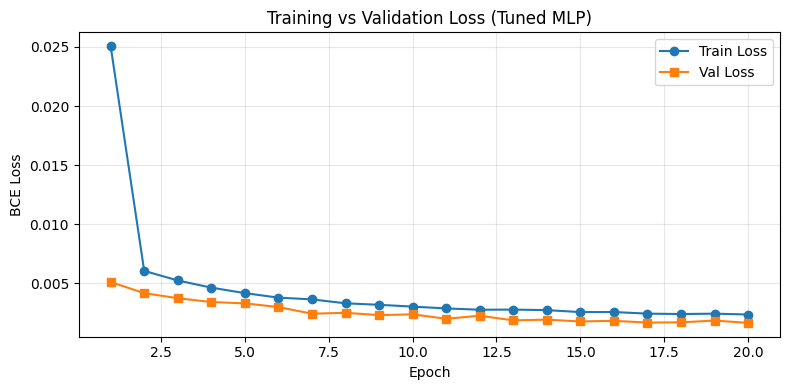

In [16]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(range(1, len(train_losses)+1), train_losses, label='Train Loss', marker='o')
ax.plot(range(1, len(val_losses)+1), val_losses, label='Val Loss', marker='s')
ax.set_xlabel('Epoch')
ax.set_ylabel('BCE Loss')
ax.set_title('Training vs Validation Loss (Tuned MLP)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# XGB Learning Curve (train vs. val) --- No Overfitting plot

In [17]:
# custom functions

def sentinel_divide(n, d):
    sentinel = -1
    safe_d = np.where(d == 0, sentinel, d)
    return n / safe_d

In [18]:
df = pd.read_parquet("../../data/processed/preprocessed_minimal.parquet")
df.shape

(2294985, 94)

In [19]:
# NFI column sort
nfi_meta = ['stub_id', 'particle_id', 'class', 'label', 'target']
element_cols = [c for c in df.columns if c not in nfi_meta]
gsr = ['pb', 'sb', 'ba']
non_gsr = sorted([c for c in element_cols if c not in gsr])
nfi_df = df[nfi_meta + gsr + non_gsr]

print(f"# of elements: {len(element_cols)}")

# of elements: 89


In [20]:
eng_df = nfi_df.copy()

# Pb * Sb
eng_df['pb_times_sb'] = eng_df['pb'] * (eng_df['sb'])

# Log (Pb + Sb)
eng_df['log_pb_plus_sb'] = np.log1p(eng_df['pb'] + eng_df['sb'])

# GSR ratios over total mass
total_mass = eng_df[element_cols].sum(axis=1)
total_mass_no_sb = total_mass - eng_df['sb']
total_mass_no_ba = total_mass - eng_df['ba']
total_mass_no_pb = total_mass - eng_df['pb']

eng_df['pb_ba_over_non_sb_mass'] = (eng_df['pb'] + eng_df['ba']) / total_mass_no_sb
eng_df['pb_sb_over_non_ba_mass'] =  (eng_df['pb'] + eng_df['sb']) / total_mass_no_ba
eng_df['ba_sb_over_non_pb_mass'] =  (eng_df['ba'] + eng_df['sb']) / total_mass_no_pb

# Brass particles
eng_df['cu_zn_over_mass'] =  (eng_df['cu'] + eng_df['zn']) / total_mass

# Titanium Zinc
eng_df['ti_zn_over_mass'] = (eng_df['ti'] + eng_df['zn']) / total_mass

# Non-Barium GSR over Non-Barium Confounders
gsr = eng_df['pb'] + eng_df['sb']
confounders = eng_df['ca'] + eng_df['si'] + eng_df['al'] + eng_df['fe'] #+ eng_df['ti'] + eng_df['zn'] + eng_df['cu']
eng_df['gsr_over_confounders'] = sentinel_divide(gsr.values, confounders.values)

# check for any 'NaN' or 'inf'
any(np.isinf(eng_df['gsr_over_confounders']) | eng_df['gsr_over_confounders'].isna())

False

In [22]:
eng_cols = [c for c in eng_df.columns if c not in nfi_meta + element_cols]
print(f"# of engineered features: {len(eng_cols)}")
print(f"\nEngineered features:")
for feat in eng_cols:
    print(f"\t{feat}")

# of engineered features: 8

Engineered features:
	pb_times_sb
	log_pb_plus_sb
	pb_ba_over_non_sb_mass
	pb_sb_over_non_ba_mass
	ba_sb_over_non_pb_mass
	cu_zn_over_mass
	ti_zn_over_mass
	gsr_over_confounders


In [23]:
feature_cols = element_cols + eng_cols
print(f"# of feature columns: {len(feature_cols)}")

# of feature columns: 97


In [24]:
X = eng_df[feature_cols].values.astype(np.float32)
y = eng_df['target'].values.astype(np.float32)
groups = eng_df['stub_id'].values

gss1 = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
trainval_idx, test_idx = next(gss1.split(X, y, groups))

X_trainval, X_test = X[trainval_idx], X[test_idx]
y_trainval, y_test = y[trainval_idx], y[test_idx]
groups_trainval = groups[trainval_idx]

gss2 = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=42)  # 25% of 80% = 20% of total
train_idx_rel, val_idx_rel = next(gss2.split(X_trainval, y_trainval, groups_trainval))

X_train = X_trainval[train_idx_rel]
X_val = X_trainval[val_idx_rel]
y_train = y_trainval[train_idx_rel]
y_val = y_trainval[val_idx_rel]

groups_train = set(groups_trainval[train_idx_rel])
groups_val = set(groups_trainval[val_idx_rel])
groups_test = set(groups[test_idx])

In [25]:
# Verify no stub leakage
assert len(groups_train & groups_val) == 0, 'Train-Val stub leak!'
assert len(groups_train & groups_test) == 0, 'Train-Test stub leak!'
assert len(groups_val & groups_test) == 0, 'Val-Test stub leak!'

print("No stub-level leakage")

No stub-level leakage


In [26]:
total_obs = len(y_train) + len(y_val) + len(y_test)

summary = pd.DataFrame({
    "Split":         ["Train",          "Val",          "Test"],
    "Observations":  [len(y_train),     len(y_val),     len(y_test)],
    "% of Total":    [len(y_train)/total_obs*100, len(y_val)/total_obs*100, len(y_test)/total_obs*100],
    "GSR (target=1)":[int(y_train.sum()), int(y_val.sum()), int(y_test.sum())],
    "GSR %":         [y_train.mean()*100, y_val.mean()*100, y_test.mean()*100],
    "Unique Stubs":  [len(groups_train), len(groups_val), len(groups_test)],
})

summary["% of Total"] = summary["% of Total"].map("{:.1f}%".format)
summary["GSR %"]      = summary["GSR %"].map("{:.2f}%".format)

print(f"Total observations : {total_obs:,}")
print(f"Total features     : {X_train.shape[1]}")
print(f"Total unique stubs : {len(groups_train | groups_val | groups_test):,}\n")
print(summary.to_string(index=False))

Total observations : 2,294,985
Total features     : 97
Total unique stubs : 3,786

Split  Observations % of Total  GSR (target=1)  GSR %  Unique Stubs
Train       1444147      62.9%          717835 49.71%          2271
  Val        407614      17.8%          151162 37.08%           757
 Test        443224      19.3%          209949 47.37%           758


In [27]:
baseline = xgb.XGBClassifier(
    n_estimators=500, max_depth=6, learning_rate=0.1,
    min_child_weight=5, reg_alpha=0.1, reg_lambda=1.0,
    subsample=0.8, colsample_bytree=0.8,
    tree_method='hist', eval_metric='aucpr',
    early_stopping_rounds=30, random_state=42, n_jobs=-1,
)

baseline.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_val, y_val)],
    verbose=10
)

[0]	validation_0-aucpr:0.99971	validation_1-aucpr:0.99985
[10]	validation_0-aucpr:0.99980	validation_1-aucpr:0.99988
[20]	validation_0-aucpr:0.99989	validation_1-aucpr:0.99994
[30]	validation_0-aucpr:0.99997	validation_1-aucpr:0.99999
[40]	validation_0-aucpr:0.99999	validation_1-aucpr:0.99999
[50]	validation_0-aucpr:0.99999	validation_1-aucpr:1.00000
[60]	validation_0-aucpr:1.00000	validation_1-aucpr:1.00000
[70]	validation_0-aucpr:1.00000	validation_1-aucpr:1.00000
[80]	validation_0-aucpr:1.00000	validation_1-aucpr:1.00000
[90]	validation_0-aucpr:1.00000	validation_1-aucpr:1.00000
[100]	validation_0-aucpr:1.00000	validation_1-aucpr:1.00000
[110]	validation_0-aucpr:1.00000	validation_1-aucpr:1.00000
[120]	validation_0-aucpr:1.00000	validation_1-aucpr:1.00000
[130]	validation_0-aucpr:1.00000	validation_1-aucpr:1.00000
[140]	validation_0-aucpr:1.00000	validation_1-aucpr:1.00000
[150]	validation_0-aucpr:1.00000	validation_1-aucpr:1.00000
[160]	validation_0-aucpr:1.00000	validation_1-aucpr

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",30
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes fro

In [28]:
results = baseline.evals_result()
train_aucpr = results['validation_0']['aucpr']
val_aucpr = results['validation_1']['aucpr']

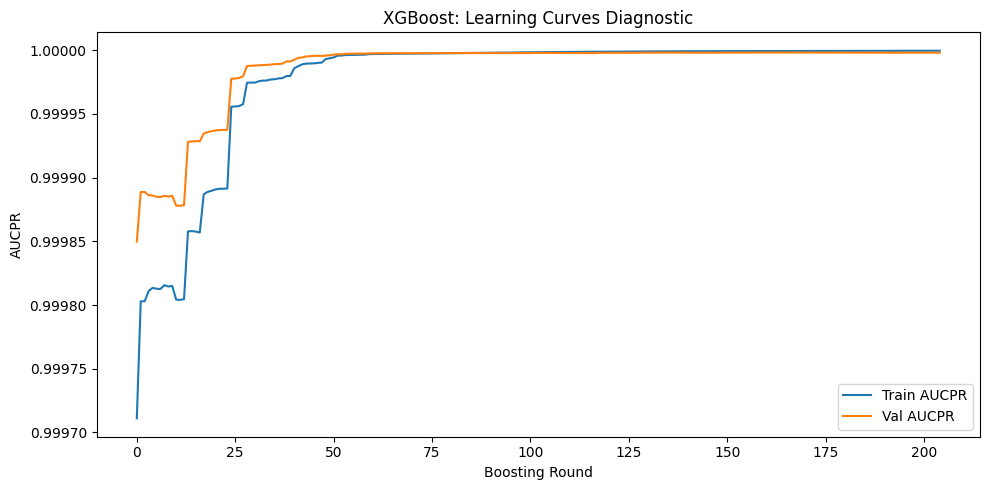

In [29]:
fig, ax = plt.subplots(1, 1, figsize=(10, 5))
ax.plot(train_aucpr, label='Train AUCPR')
ax.plot(val_aucpr, label='Val AUCPR')
ax.set_xlabel('Boosting Round')
ax.set_ylabel('AUCPR')
ax.set_title('XGBoost: Learning Curves Diagnostic')
ax.legend()
plt.tight_layout()
plt.savefig('xgb_learning_curves_final.png', dpi=150)
plt.show()

# Plots to Check for Overfitting & Ablation

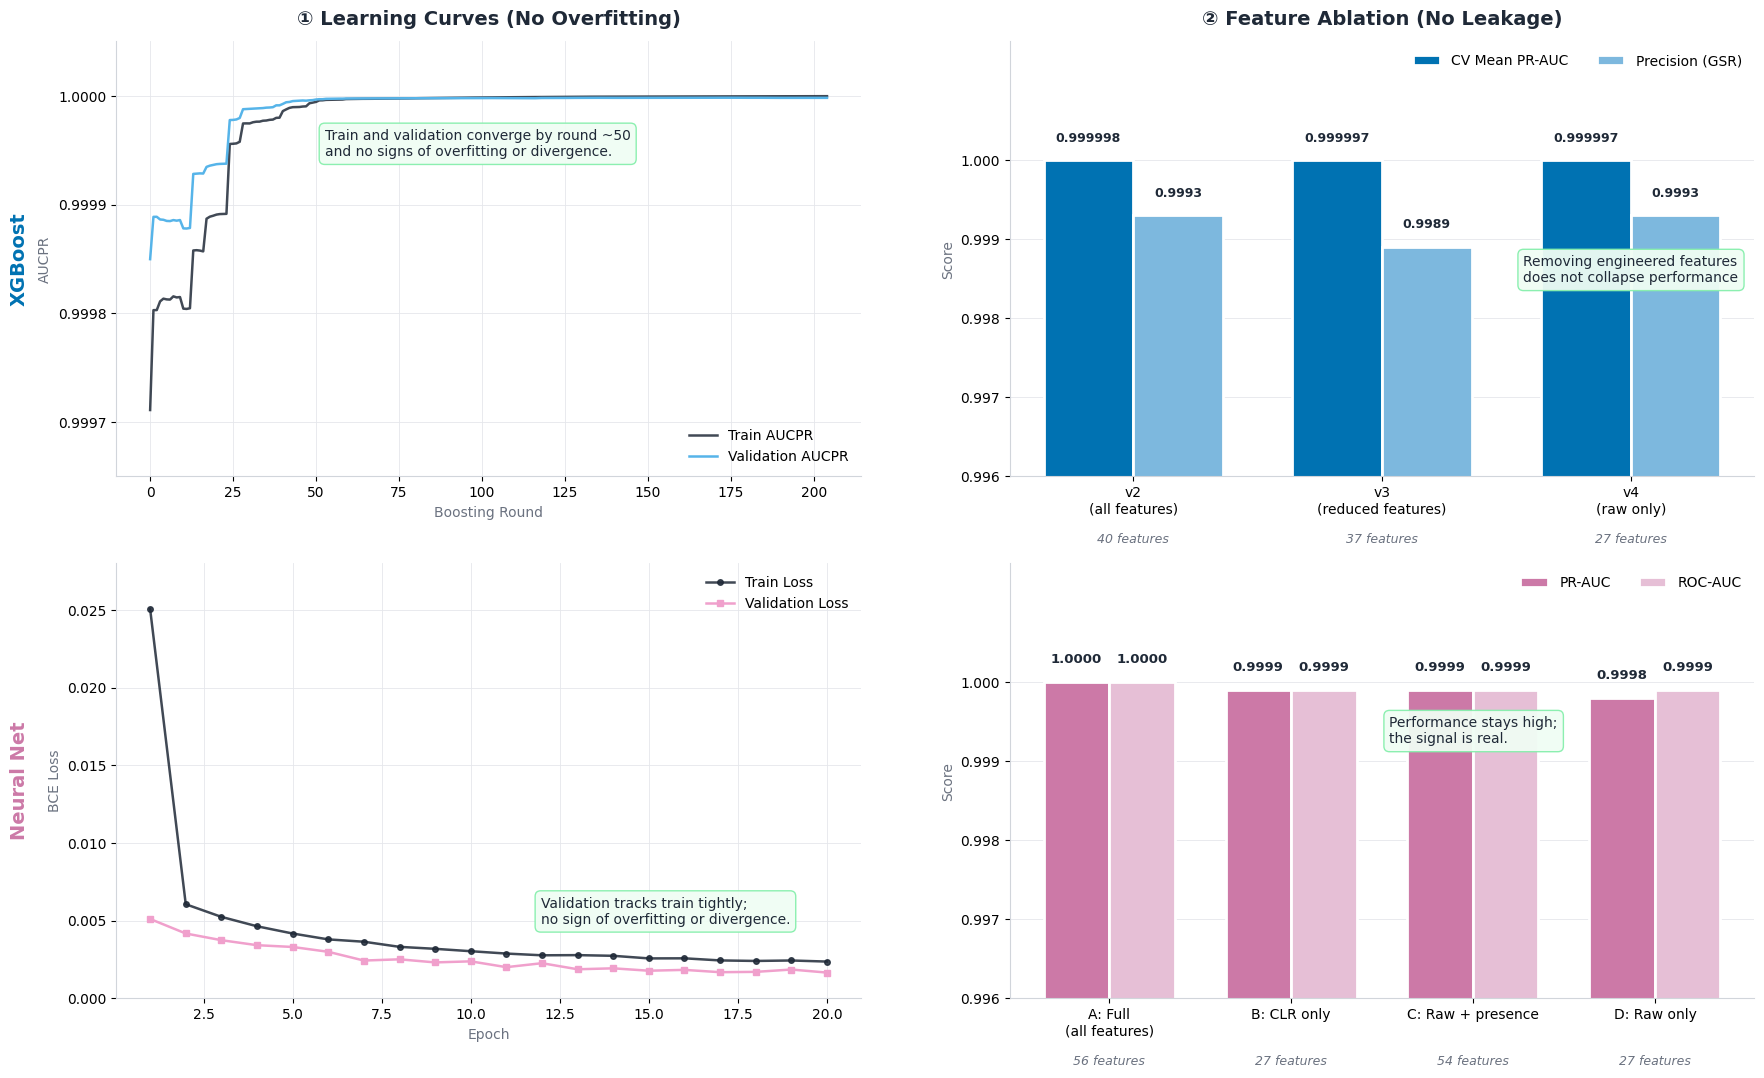

In [72]:
# ---------- Colors ----------
XGB_COLOR     = '#0072B2'  # Okabe-Ito blue
NN_COLOR      = '#CC79A7'  # Okabe-Ito magenta
TRAIN_COLOR   = '#1F2937'  # near-black for train line
VAL_COLOR_XGB = '#56B4E9'  # sky blue for XGB validation
VAL_COLOR_NN  = '#F0A0CC'  # lighter pink for NN validation
INK   = '#1F2937'
MUTED = '#6B7280'
GRID  = '#E5E7EB'

plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'axes.edgecolor': '#D1D5DB',
})

# --- XGB ablation: v2 / v3 / v4 with CV Mean PR-AUC and Precision (GSR) ---
xgb_ablation = {
    'v2\n(all features)': {'pr_auc': 0.999998, 'precision': 0.9993, 'features': 40},
    'v3\n(reduced features)':  {'pr_auc': 0.999997, 'precision': 0.9989, 'features': 37},
    'v4\n(raw only)':   {'pr_auc': 0.999997, 'precision': 0.9993, 'features': 27},
}

# --- NN ablation: A/B/C/D with PR-AUC and ROC-AUC ---
nn_ablation = {
    'A: Full\n(all features)':   {'pr_auc': 1.0000, 'roc_auc': 1.0000, 'features': 56},
    'B: CLR only':               {'pr_auc': 0.9999, 'roc_auc': 0.9999, 'features': 27},
    'C: Raw + presence':         {'pr_auc': 0.9999, 'roc_auc': 0.9999, 'features': 54},
    'D: Raw only':               {'pr_auc': 0.9998, 'roc_auc': 0.9999, 'features': 27},
}

# =========================================================================
# Figure
# =========================================================================
fig = plt.figure(figsize=(18, 11), facecolor='white')
gs = GridSpec(
    nrows=2, ncols=2,
    height_ratios=[1.0, 1.0],
    hspace=0.20, wspace=0.20,
    left=0.06, right=0.97, top=0.93, bottom=0.06,
)

# =========================================================================
# Row 1, Col 1 XGBoost learning curve
# =========================================================================
ax = fig.add_subplot(gs[0, 0])
ax.set_title('① Learning Curves (No Overfitting)', fontsize=14, fontweight='bold', color=INK, pad=12, loc='center')
ax.plot(train_aucpr, color=TRAIN_COLOR, linewidth=1.8,
        label='Train AUCPR', alpha=0.85)
ax.plot(val_aucpr, color=VAL_COLOR_XGB, linewidth=1.8,
        label='Validation AUCPR')
ax.set_xlabel('Boosting Round', fontsize=10, color=MUTED)
ax.set_ylabel('AUCPR', fontsize=10, color=MUTED)
ax.set_ylim(0.99965, 1.00005)
ax.set_yticks([0.9997, 0.9998, 0.9999, 1.0000])
ax.set_yticklabels(['0.9997', '0.9998', '0.9999', '1.0000'])
ax.legend(loc='lower right', fontsize=10, frameon=False)
ax.grid(True, color=GRID, linewidth=0.6)
ax.set_axisbelow(True)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.text(-0.13, 0.5, 'XGBoost',
        rotation=90, ha='center', va='center', fontsize=14,
        fontweight='bold', color=XGB_COLOR, transform=ax.transAxes)

ax.text(0.28, 0.73,
        'Train and validation converge by round ~50\nand no signs of overfitting or divergence.',
        transform=ax.transAxes, ha='left', va='bottom',
        fontsize=10, color=INK,
        bbox=dict(boxstyle='round,pad=0.4', facecolor='#F0FDF4',
                  edgecolor='#86EFAC', linewidth=1, alpha=0.95))

# =========================================================================
# Row 1, Col 2 XGBoost ablation
# =========================================================================
ax = fig.add_subplot(gs[0, 1])
ax.set_title('② Feature Ablation (No Leakage)', fontsize=14, fontweight='bold', color=INK, pad=12, loc='center')
labels_xgb = list(xgb_ablation.keys())
pr_xgb     = [xgb_ablation[k]['pr_auc']    for k in labels_xgb]
acc_xgb    = [xgb_ablation[k]['precision'] for k in labels_xgb]
feats_xgb  = [xgb_ablation[k]['features']  for k in labels_xgb]

XGB_LIGHT = '#7DB8DE'
x_pos = np.arange(len(labels_xgb))
bar_w = 0.36

bars_pr  = ax.bar(x_pos - bar_w/2, pr_xgb,  bar_w, color=XGB_COLOR,
                  edgecolor='white', linewidth=2, label='CV Mean PR-AUC')
bars_acc = ax.bar(x_pos + bar_w/2, acc_xgb, bar_w, color=XGB_LIGHT,
                  edgecolor='white', linewidth=2, label='Precision (GSR)')

for bar, val in zip(bars_pr, pr_xgb):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.0002,
            f'{val:.6f}', ha='center', va='bottom',
            fontsize=9, fontweight='bold', color=INK)
for bar, val in zip(bars_acc, acc_xgb):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.0002,
            f'{val:.4f}', ha='center', va='bottom',
            fontsize=9, fontweight='bold', color=INK)

for xpos, n in zip(x_pos, feats_xgb):
    ax.text(xpos, -0.13, f'{n} features',
            ha='center', va='top', fontsize=9, color=MUTED, style='italic',
            transform=ax.get_xaxis_transform())

ax.set_xticks(x_pos)
ax.set_xticklabels(labels_xgb, fontsize=10)
ax.set_ylabel('Score', fontsize=10, color=MUTED)
ax.set_ylim(0.996, 1.0015)
ax.set_yticks([0.996, 0.997, 0.998, 0.999, 1.000])
ax.set_yticklabels(['0.996', '0.997', '0.998', '0.999', '1.000'])
ax.legend(loc='upper right', fontsize=10, frameon=False, ncol=2)
ax.grid(True, axis='y', color=GRID, linewidth=0.6)
ax.set_axisbelow(True)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.text(0.69, 0.44,
        'Removing engineered features\ndoes not collapse performance',
        transform=ax.transAxes, ha='left', va='bottom',
        fontsize=10, color=INK,
        bbox=dict(boxstyle='round,pad=0.4', facecolor='#F0FDF4',
                  edgecolor='#86EFAC', linewidth=1, alpha=0.95))

# =========================================================================
# Row 2, Col 1 Neural Net learning curve
# =========================================================================
ax = fig.add_subplot(gs[1, 0])
ax.plot(range(1, len(train_losses)+1), train_losses, color=TRAIN_COLOR, linewidth=1.8,
        marker='o', markersize=4, label='Train Loss', alpha=0.85)
ax.plot(range(1, len(val_losses)+1), val_losses, color=VAL_COLOR_NN, linewidth=1.8,
        marker='s', markersize=4, label='Validation Loss')
ax.set_xlabel('Epoch', fontsize=10, color=MUTED)
ax.set_ylabel('BCE Loss', fontsize=10, color=MUTED)
ax.set_ylim(0, 0.028)
ax.legend(loc='upper right', fontsize=10, frameon=False)
ax.grid(True, color=GRID, linewidth=0.6)
ax.set_axisbelow(True)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.text(-0.13, 0.5, 'Neural Net',
        rotation=90, ha='center', va='center', fontsize=14,
        fontweight='bold', color=NN_COLOR, transform=ax.transAxes)

ax.text(0.57, 0.20,
        'Validation tracks train tightly;\nno sign of overfitting or divergence.',
        transform=ax.transAxes, ha='left', va='center',
        fontsize=10, color=INK,
        bbox=dict(boxstyle='round,pad=0.4', facecolor='#F0FDF4',
                  edgecolor='#86EFAC', linewidth=1, alpha=0.95))

# =========================================================================
# Row 2, Col 2 NN ablation
# =========================================================================
ax = fig.add_subplot(gs[1, 1])
labels_nn = list(nn_ablation.keys())
vals_nn   = [nn_ablation[k]['pr_auc']  for k in labels_nn]
acc_nn    = [nn_ablation[k]['roc_auc'] for k in labels_nn]
feats_nn  = [nn_ablation[k]['features'] for k in labels_nn]

NN_LIGHT = '#E6BFD6'
x_pos_nn = np.arange(len(labels_nn))
bar_w = 0.36

bars_pr  = ax.bar(x_pos_nn - bar_w/2, vals_nn, bar_w, color=NN_COLOR,
                  edgecolor='white', linewidth=2, label='PR-AUC')
bars_acc = ax.bar(x_pos_nn + bar_w/2, acc_nn,  bar_w, color=NN_LIGHT,
                  edgecolor='white', linewidth=2, label='ROC-AUC')

for bar, val in zip(bars_pr, vals_nn):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.0002,
            f'{val:.4f}', ha='center', va='bottom',
            fontsize=9.5, fontweight='bold', color=INK)
for bar, val in zip(bars_acc, acc_nn):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.0002,
            f'{val:.4f}', ha='center', va='bottom',
            fontsize=9.5, fontweight='bold', color=INK)

for xpos, n in zip(x_pos_nn, feats_nn):
    ax.text(xpos, -0.13, f'{n} features',
            ha='center', va='top', fontsize=9, color=MUTED, style='italic',
            transform=ax.get_xaxis_transform())

ax.set_xticks(x_pos_nn)
ax.set_xticklabels(labels_nn, fontsize=10)
ax.set_ylabel('Score', fontsize=10, color=MUTED)
ax.set_ylim(0.9996, 1.0015)
ax.set_yticks([0.996, 0.997, 0.998, 0.999, 1.000])
ax.set_yticklabels(['0.996', '0.997', '0.998', '0.999', '1.000'])
ax.legend(loc='upper right', fontsize=10, frameon=False, ncol=2)
ax.grid(True, axis='y', color=GRID, linewidth=0.6)
ax.set_axisbelow(True)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.text(0.51, 0.58,
        'Performance stays high;\nthe signal is real.',
        transform=ax.transAxes, ha='left', va='bottom',
        fontsize=10, color=INK,
        bbox=dict(boxstyle='round,pad=0.4', facecolor='#F0FDF4',
                  edgecolor='#86EFAC', linewidth=1, alpha=0.95))

plt.show()